In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
df = pd.read_csv("dynamic_pricing.csv")
df

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422
...,...,...,...,...,...,...,...,...,...,...
995,33,23,Urban,Gold,24,4.21,Morning,Premium,11,91.389526
996,84,29,Urban,Regular,92,4.55,Morning,Premium,94,424.155987
997,44,6,Suburban,Gold,80,4.13,Night,Premium,40,157.364830
998,53,27,Suburban,Regular,78,3.63,Night,Premium,58,279.095048


In [27]:
# Display the first 5 rows

df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [28]:
# Display the number of rows and columns

df.shape

(1000, 10)

In [29]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [30]:
# Display statistical summary of the dataset

df.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


In [31]:
# Check the number of missing values in each column

df.isnull().sum()

Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

In [32]:
# Fill missing values in numerical columns with the mean

df.fillna(df.mean(numeric_only=True), inplace=True)

In [33]:
# Fill missing values in categorical columns with the most frequent value

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_25248\1254743931.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [34]:
# Convert text columns into numerical values using Label Encoding

encoder = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = encoder.fit_transform(df[col])

# Display updated dataset

df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,2,2,13,4.47,3,1,90,284.257273
1,58,39,1,2,72,4.06,1,0,43,173.874753
2,42,31,0,2,0,3.99,0,1,76,329.795469
3,89,28,0,1,67,4.31,0,1,134,470.201232
4,78,22,0,1,74,3.77,0,0,149,579.681422


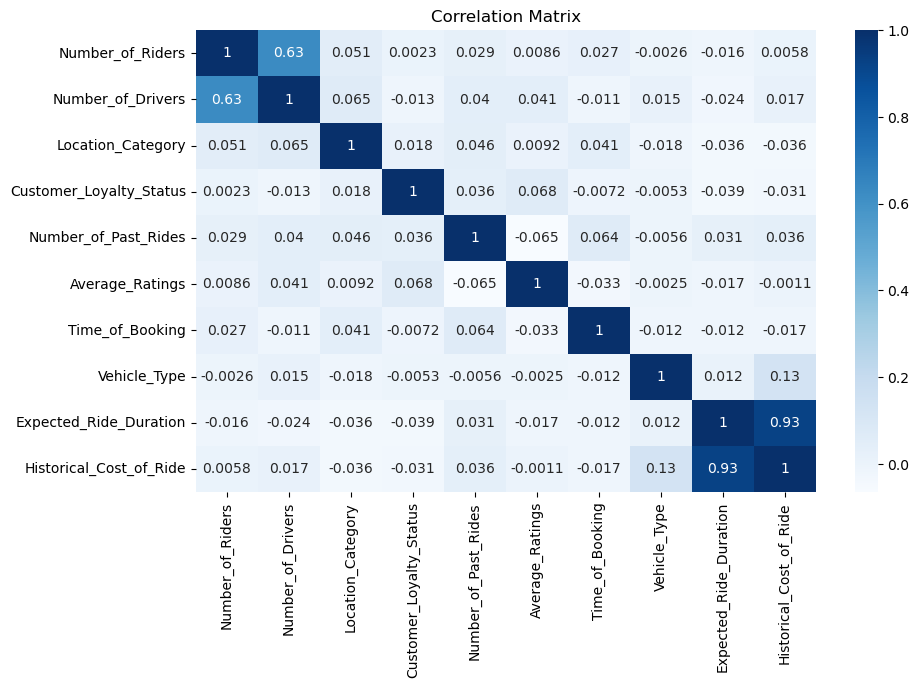

In [35]:
# Display the correlation between all features

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Matrix")

plt.show()

In [38]:
# Select input features and target variable

X = df.drop("Historical_Cost_of_Ride", axis=1)
print(X)
y = df["Historical_Cost_of_Ride"]
print(y)

     Number_of_Riders  Number_of_Drivers  Location_Category  \
0                  90                 45                  2   
1                  58                 39                  1   
2                  42                 31                  0   
3                  89                 28                  0   
4                  78                 22                  0   
..                ...                ...                ...   
995                33                 23                  2   
996                84                 29                  2   
997                44                  6                  1   
998                53                 27                  1   
999                78                 63                  0   

     Customer_Loyalty_Status  Number_of_Past_Rides  Average_Ratings  \
0                          2                    13             4.47   
1                          2                    72             4.06   
2                          2  

In [40]:
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [42]:
# Predict ride cost using the testing dataset

y_pred = model.predict(X_test)

In [43]:
# Evaluate model performance using MAE, MSE, and R² Score

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))

print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 52.724635154956246
Mean Squared Error (MSE): 4574.053712786405
R2 Score: 0.8745487387599429


In [44]:
# Create a table to compare actual and predicted ride costs

result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

# Display first 10 predictions

result.head(10)

,Actual Price,Predicted Price
521,470.269024,389.421403
737,286.409294,279.936167
740,552.269375,659.258365
660,267.740417,341.378970
411,111.112715,106.754773
678,359.128113,369.885634
626,173.887474,181.162789
513,196.315142,213.725021
859,555.401937,451.346077
136,163.214583,135.318609


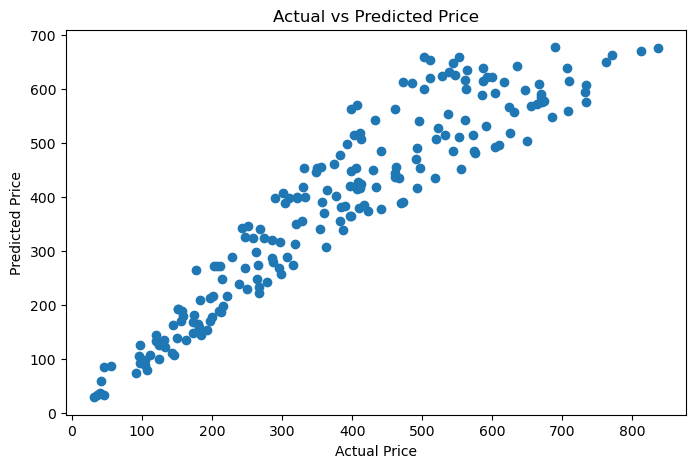

In [45]:
# Plot Actual Price vs Predicted Price

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

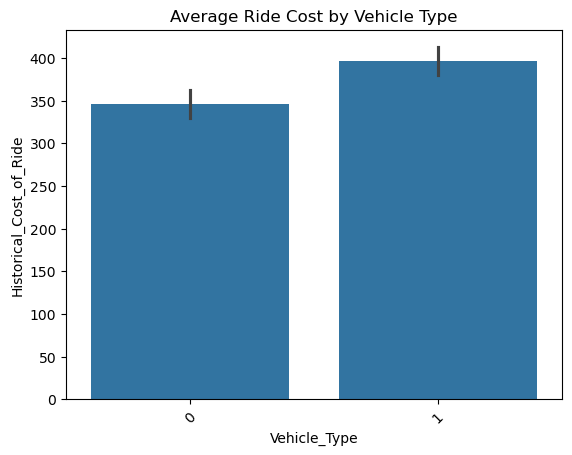

In [46]:
# Display average ride cost for each vehicle type

sns.barplot(
    data=df,
    x="Vehicle_Type",
    y="Historical_Cost_of_Ride"
)

plt.xticks(rotation=45)

plt.title("Average Ride Cost by Vehicle Type")

plt.show()

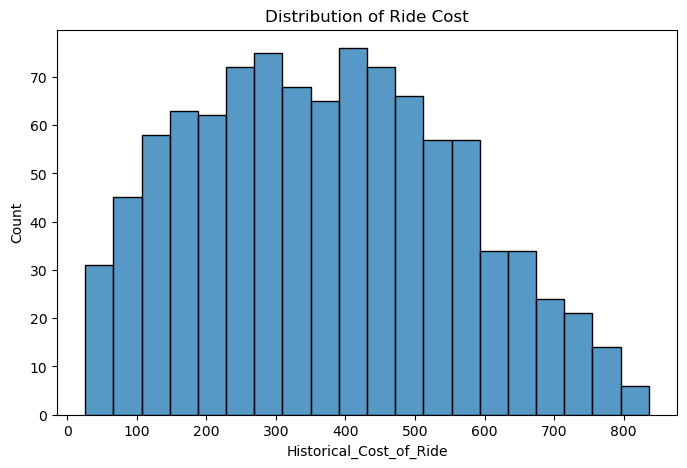

In [48]:
# Display the distribution of ride costs

plt.figure(figsize=(8,5))

sns.histplot(
    df["Historical_Cost_of_Ride"],
    bins=20
)

plt.title("Distribution of Ride Cost")

plt.show()

In [49]:
# Display sample predictions

print("Sample Predictions")

print(result.head())

Sample Predictions
     Actual Price  Predicted Price
521    470.269024       389.421403
737    286.409294       279.936167
740    552.269375       659.258365
660    267.740417       341.378970
411    111.112715       106.754773


In [50]:
# Display all column names in the dataset

print(df.columns.tolist())

['Number_of_Riders', 'Number_of_Drivers', 'Location_Category', 'Customer_Loyalty_Status', 'Number_of_Past_Rides', 'Average_Ratings', 'Time_of_Booking', 'Vehicle_Type', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride']
